In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, confusion_matrix, hamming_loss
from imblearn.over_sampling import SMOTE


In [ ]:
# Set aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# Load data
df = pd.read_csv('ai4i2020.csv')

In [6]:
# Display first 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
df.shape

(10000, 14)

In [9]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [10]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [11]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


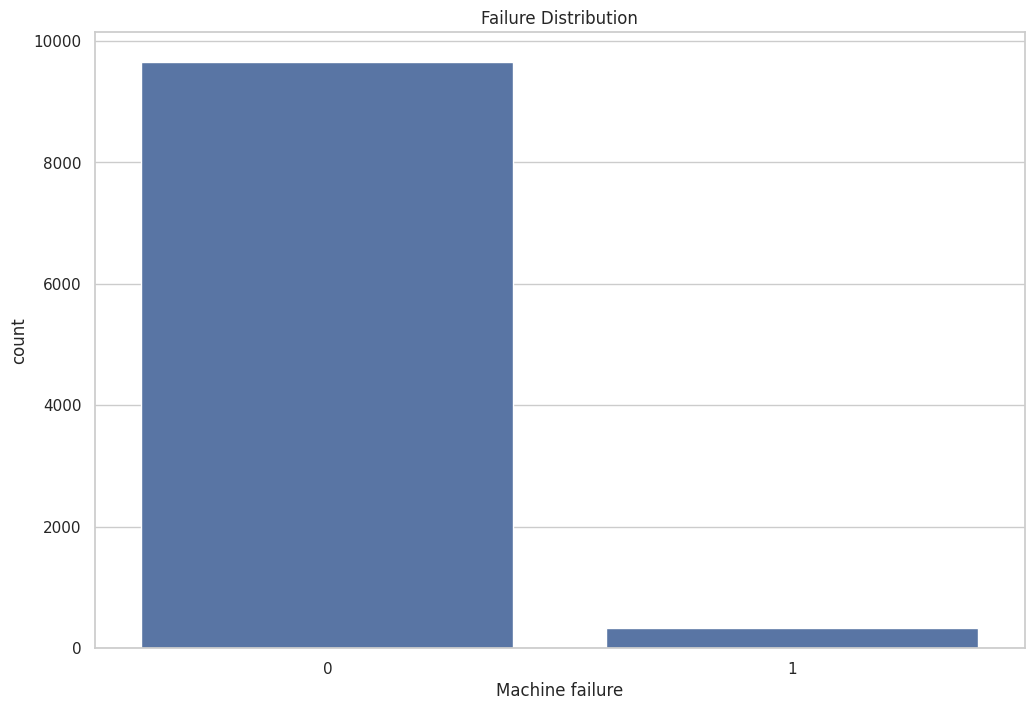

In [12]:
sns.countplot(x='Machine failure', data=df)
plt.title("Failure Distribution")
plt.show()

/tmp/ipython-input-4110570537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')


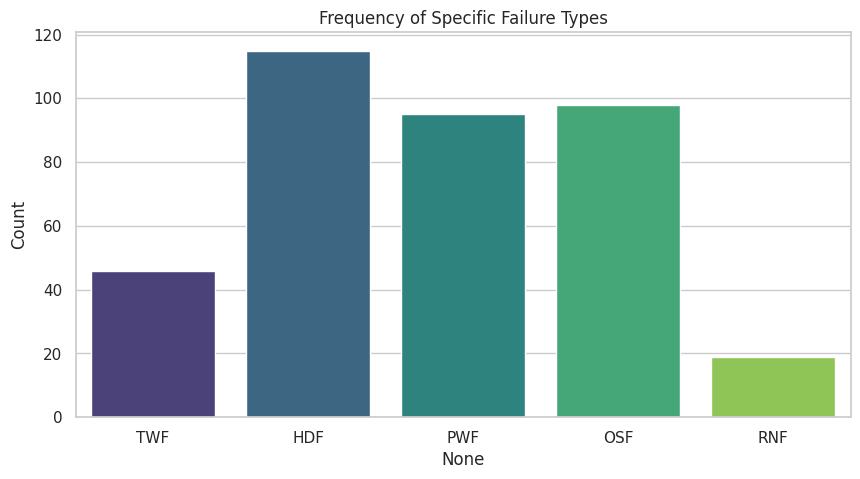

In [ ]:
### 1. Target Distribution (The Imbalance)
failure_counts = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()
plt.figure(figsize=(10, 5))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')
plt.title('Frequency of Specific Failure Types')
plt.ylabel('Count')
plt.show()

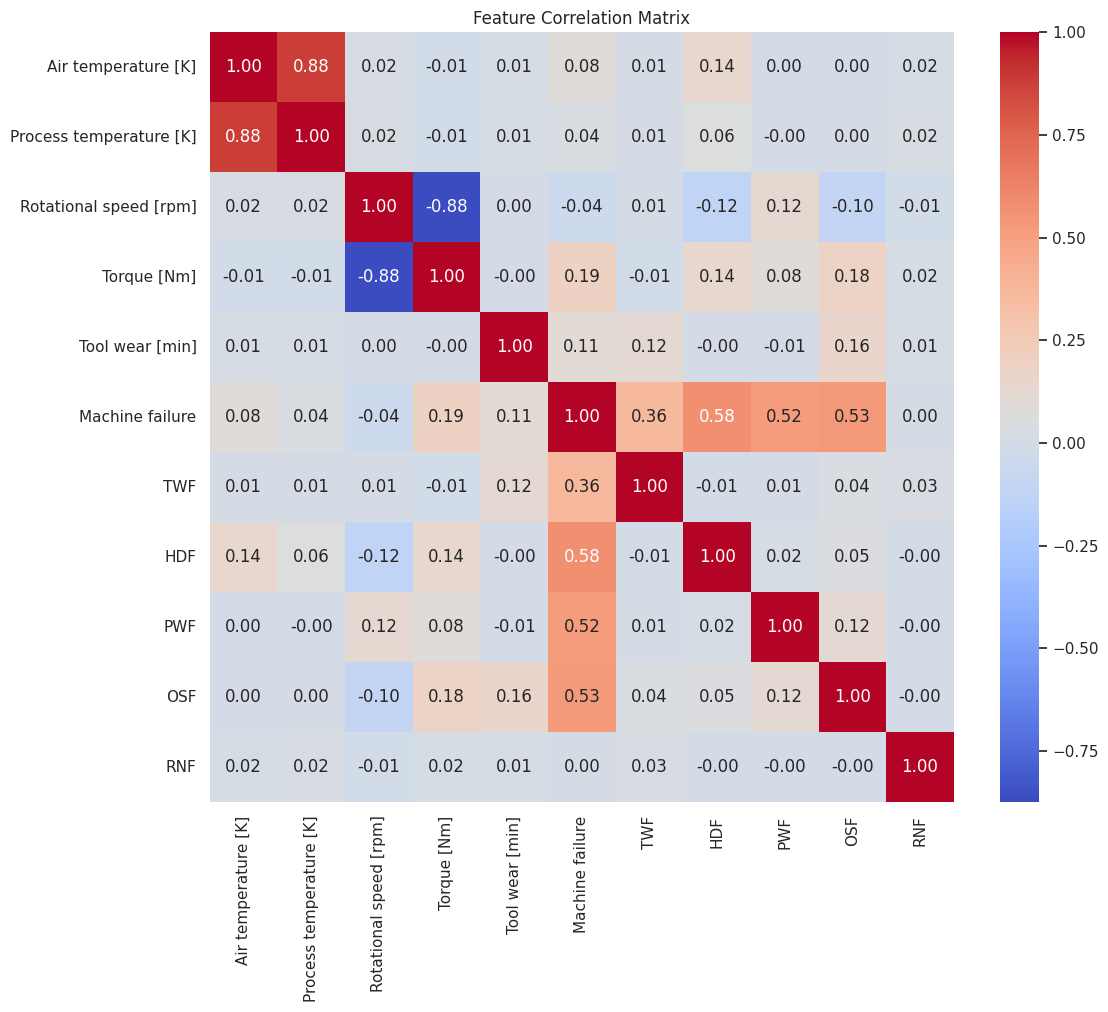

In [ ]:
### 2. Correlation Heatmap
# Dropping non-numeric for correlation
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(['UDI', 'Product ID', 'Type'], axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [13]:
def engineer_features(data):
    # 1. Temperature Difference (Critical for HDF)
    data['Temp_Diff'] = data['Process temperature [K]'] - data['Air temperature [K]']

    # 2. Power Factor (Torque * RPM) - (Critical for PWF)
    # Power is proportional to Torque * Rotational Speed
    data['Power'] = data['Torque [Nm]'] * data['Rotational speed [rpm]']

    # 3. Overstrain Factor (Tool Wear * Torque) - (Critical for OSF)
    data['Overstrain'] = data['Tool wear [min]'] * data['Torque [Nm]']

    return data

df_eng = engineer_features(df.copy())

In [15]:
df_eng

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temp_Diff,Power,Overstrain
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,138.9
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,247.0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,276.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,360.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,47318.0,413.0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,51897.6,540.6
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,54943.0,734.8
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,68288.0,1212.5


In [16]:
# Clean and Encode
X = df_eng.drop(['UDI', 'Product ID', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df_eng[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']]

In [17]:
# Encode 'Type' (L/M/H)
le = LabelEncoder()
X['Type'] = le.fit_transform(X['Type'])

In [18]:
# Train-Test Split (Stratified by the main failure indicator)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y['Machine failure'])

In [24]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Handling Imbalance with SMOTE (on the training set only)
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
sm = SMOTE(random_state=42)

# 2. Resample X based ONLY on the 'Machine failure' column
# We use fit_resample on the first column of y_train
X_res, y_res_main = sm.fit_resample(X_train_scaled, y_train['Machine failure'])

# 3. GET THE INDICES (The Robust Way)
# Since 'sample_indices_' is version-dependent, we use this trick:
# We resample an index array to see which rows SMOTE picked/created
indices = np.arange(len(X_train_scaled))
resampled_indices, _ = sm.fit_resample(indices.reshape(-1, 1), y_train['Machine failure'])
resampled_indices = resampled_indices.flatten()

# 4. Reconstruct the full Multi-label y_res
y_res = y_train.iloc[resampled_indices]

print(f"Resampled X shape: {X_res.shape}")
print(f"Resampled Y shape: {y_res.shape}")
print("Class counts in resampled data:")
print(y_res['Machine failure'].value_counts())

Resampled X shape: (15458, 9)
Resampled Y shape: (15458, 6)
Class counts in resampled data:
Machine failure
0    14599
1      859
Name: count, dtype: int64


In [29]:
#Instead of just listing accuracy (which is useless for imbalanced data), focus on Macro F1-Score and Hamming Loss.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, hamming_loss

# Define models to compare
comparison_models = {
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(max_iter=1000)),
    "Random Forest": MultiOutputClassifier(RandomForestClassifier(n_estimators=100)),
    "XGBoost": MultiOutputClassifier(XGBClassifier(eval_metric='logloss'))
}

results = []

for name, clf in comparison_models.items():
    clf.fit(X_res, y_res)
    predictions = clf.predict(X_test_scaled)

    # Calculate metrics
    f1 = f1_score(y_test, predictions, average='macro')
    h_loss = hamming_loss(y_test, predictions)

    results.append({"Model": name, "F1-Score": f1, "Hamming Loss": h_loss})

# Display as a DataFrame
comparison_df = pd.DataFrame(results)
print(comparison_df)

                 Model  F1-Score  Hamming Loss
0  Logistic Regression  0.004831      0.011583
1        Random Forest  0.004831      0.011583
2              XGBoost  0.132282      0.010917


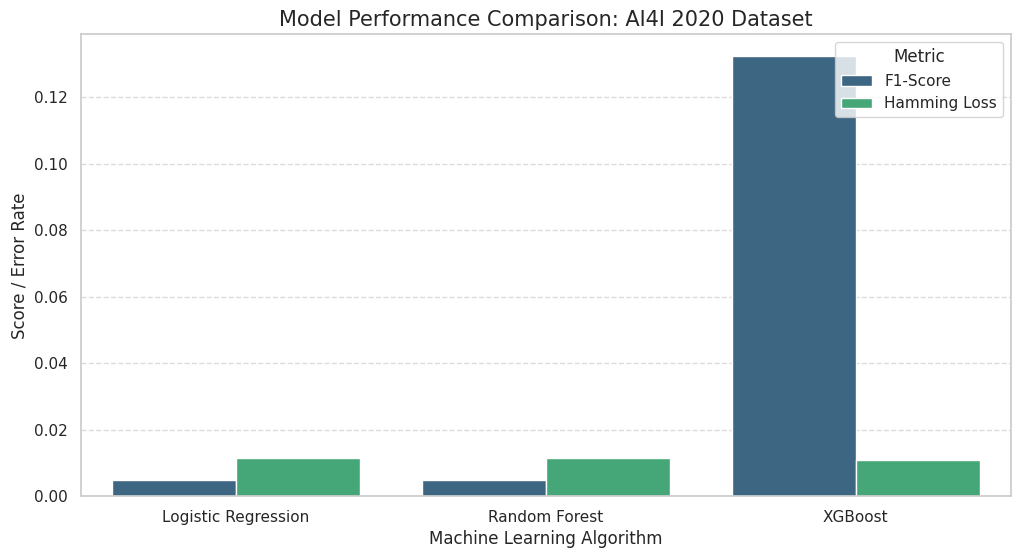

In [30]:
# Convert results to a long format for easier plotting with Seaborn
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x="Model", y="Value", hue="Metric", palette="viridis")

plt.title("Model Performance Comparison: AI4I 2020 Dataset", fontsize=15)
plt.ylabel("Score / Error Rate")
plt.xlabel("Machine Learning Algorithm")
plt.legend(title="Metric", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

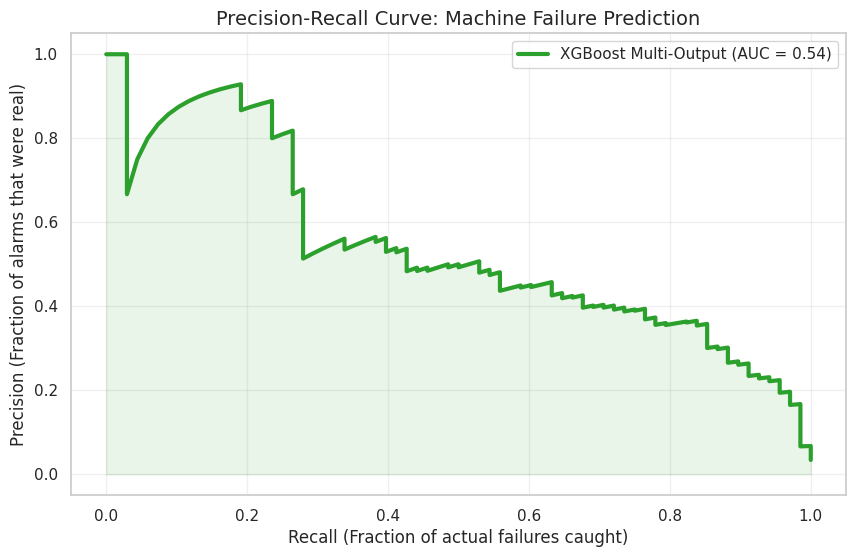

In [33]:
from sklearn.metrics import precision_recall_curve, auc

# 1. Ensure the model is fitted (using the resampled data from our SMOTE step)
# This ensures the 'model' object is alive and trained
model.fit(X_res, y_res)

# 2. Now get probabilities for all 6 targets
# This returns a list of arrays: [Target0_probs, Target1_probs, ...]
probs_list = model.predict_proba(X_test_scaled)

# 3. Extract probability for 'Machine failure' (The first target, index 0)
# We want the probability of class '1' (Failure), which is the second column [:, 1]
y_pred_probs_failure = probs_list[0][:, 1]

# 4. Generate PR Curve data
precision, recall, thresholds = precision_recall_curve(y_test.iloc[:, 0], y_pred_probs_failure)
pr_auc = auc(recall, precision)

# 5. Professional Visualization
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'XGBoost Multi-Output (AUC = {pr_auc:.2f})', color='#2ca02c', lw=3)
plt.fill_between(recall, precision, alpha=0.1, color='#2ca02c')

plt.xlabel('Recall (Fraction of actual failures caught)')
plt.ylabel('Precision (Fraction of alarms that were real)')
plt.title('Precision-Recall Curve: Machine Failure Prediction', fontsize=14)
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

Best Threshold: 0.0891
Best F-Score: 0.5309
Precision: 0.4574, Recall: 0.6324


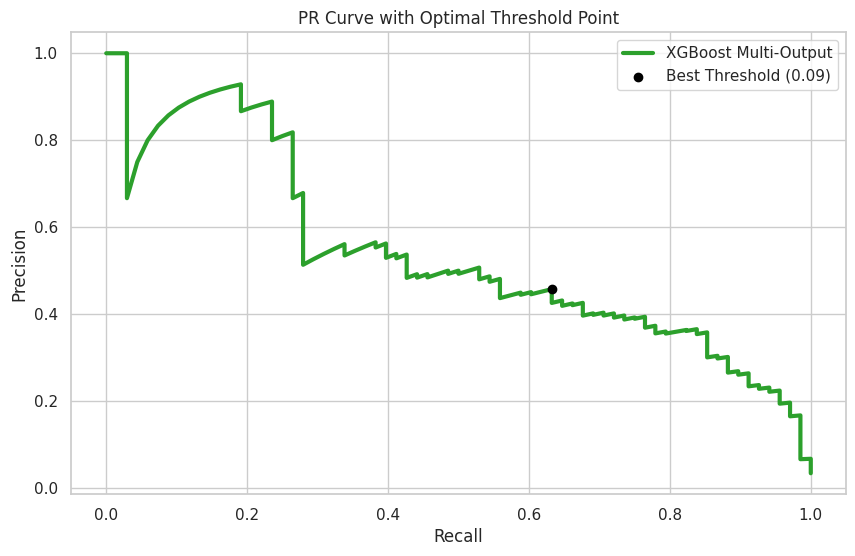

In [34]:
# Calculate F-score for each threshold
# Small epsilon added to avoid division by zero
fscore = (2 * precision * recall) / (precision + recall + 1e-10)

# Find the index of the maximum F-score
ix = np.argmax(fscore)
best_thresh = thresholds[ix]

print(f'Best Threshold: {best_thresh:.4f}')
print(f'Best F-Score: {fscore[ix]:.4f}')
print(f'Precision: {precision[ix]:.4f}, Recall: {recall[ix]:.4f}')

# Plotting the optimal point on your curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label='XGBoost Multi-Output', color='#2ca02c', lw=3)
plt.scatter(recall[ix], precision[ix], marker='o', color='black', label=f'Best Threshold ({best_thresh:.2f})', zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve with Optimal Threshold Point')
plt.legend()
plt.show()

In [37]:
def predict_maintenance_report(sensor_input_raw):
    """
    Takes raw sensor data, scales it, and returns a maintenance action report.
    """
    # 1. Engineering features (Must match your training logic)
    # sensor_input_raw should be a DataFrame row or dict

    # 2. Scale features
    # scaled_input = scaler.transform(sensor_input_raw)

    # 3. Get probabilities
    probs = model.predict_proba(scaled_input)
    fail_prob = probs[0][0][1] # Probability of 'Machine failure'

    if fail_prob >= best_thresh:
        # Determine likely reason
        reasons = []
        for i, col in enumerate(['TWF', 'HDF', 'PWF', 'OSF', 'RNF']):
            if probs[i+1][0][1] > 0.3: # Threshold for specific type
                reasons.append(col)

        return f"⚠️ ALERT: Failure Predicted ({fail_prob:.2%}). Likely causes: {', '.join(reasons)}"

    return "✅ Machine Healthy."

In [38]:
import joblib
# Save these from your notebook session
joblib.dump(model, 'maintenance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'type_encoder.pkl')

['type_encoder.pkl']